# 🎓 FINAL PRAKTIKUM DATA MINING - KELAS B
## Analisis Credit Card Default: Klasifikasi SVM & Clustering K-Means

**Kelompok:** [Isi Nomor Kelompok Anda]

**Anggota:**
1. [Nama Anggota 1] - [NIM]
2. [Nama Anggota 2] - [NIM]
3. [Nama Anggota 3] - [NIM]

---

**Dataset:** Default of Credit Card Clients Dataset  
**Source:** UCI Machine Learning Repository  
**Jumlah Data:** 30,000 records  
**Jumlah Fitur:** 24 fitur (23 fitur + 1 target)

**Metode yang Digunakan:**
1. **Klasifikasi:** Support Vector Machine (SVM) 
   - Berbagai kernel: Linear, RBF, Polynomial
   - Hyperparameter Tuning dengan GridSearchCV
   - Evaluasi: Confusion Matrix, Accuracy, Precision, Recall, F1-Score, ROC-AUC

2. **Clustering:** K-Means Clustering
   - Elbow Method untuk menentukan k optimal
   - Silhouette Score untuk evaluasi kualitas cluster
   - Analisis karakteristik setiap cluster

**Tujuan:**
- Memprediksi apakah nasabah akan default pembayaran kartu kredit bulan depan (Supervised Learning)
- Mengelompokkan nasabah berdasarkan pola perilaku kredit (Unsupervised Learning)
- Mencari kombinasi hyperparameter optimal untuk model SVM terbaik

In [1]:
# ========================================
# IMPORT LIBRARY YANG DIPERLUKAN
# ========================================

# Library Dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn

# Library Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Library Klasifikasi (SVM)
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc, roc_auc_score)

# Library Clustering (K-Means)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Library Visualisasi
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

# Setting
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Semua library berhasil diimport!")
print(f"Versi Pandas: {pd.__version__}")
print(f"Versi NumPy: {np.__version__}")
print(f"Versi Scikit-learn: {sklearn.__version__}")

✅ Semua library berhasil diimport!
Versi Pandas: 2.3.3
Versi NumPy: 2.3.5
Versi Scikit-learn: 1.7.2


In [3]:
# ========================================
# LOAD DATASET
# ========================================

# Baca dari file XLS
print("Loading dataset dari file XLS...")
df_xls = pd.read_excel('datasets/default of credit card clients.xls', header=1)

# Konversi ke CSV untuk kemudahan ke depannya
csv_path = 'datasets/credit_card_default.csv'
df_xls.to_csv(csv_path, index=False)
print(f"Dataset berhasil dikonversi ke CSV: {csv_path}")

# Load dari CSV
df = pd.read_csv(csv_path)

# Rename kolom target untuk kemudahan
df.rename(columns={'default payment next month': 'TARGET'}, inplace=True)


Loading dataset dari file XLS...
Dataset berhasil dikonversi ke CSV: datasets/credit_card_default.csv


In [4]:
# Informasi dataset
print("\n" + "="*60)
print("INFORMASI DATASET")
print("="*60)
print(f"Dimensi Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n Nama Kolom:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

# Melihat 5 baris pertama dan statistik deskriptif
print("\nSample Data (5 baris pertama):")
display(df.head())

# Melihat statistik deskriptif
print("\nStatistik Deskriptif:")
display(df.describe().T)


INFORMASI DATASET
Dimensi Dataset: 30000 rows × 25 columns
Memory Usage: 5.72 MB

 Nama Kolom:
  1. ID
  2. LIMIT_BAL
  3. SEX
  4. EDUCATION
  5. MARRIAGE
  6. AGE
  7. PAY_0
  8. PAY_2
  9. PAY_3
  10. PAY_4
  11. PAY_5
  12. PAY_6
  13. BILL_AMT1
  14. BILL_AMT2
  15. BILL_AMT3
  16. BILL_AMT4
  17. BILL_AMT5
  18. BILL_AMT6
  19. PAY_AMT1
  20. PAY_AMT2
  21. PAY_AMT3
  22. PAY_AMT4
  23. PAY_AMT5
  24. PAY_AMT6
  25. TARGET

Sample Data (5 baris pertama):


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Statistik Deskriptif:


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


---
# BAGIAN 1: EXPLORATORY DATA ANALYSIS (EDA)
---

## 1.1 Pengecekan Kualitas Data

In [5]:
# ========================================
# CEK KUALITAS DATA
# ========================================

print("🔍 PENGECEKAN KUALITAS DATA")
print("="*60)

# 1. Missing Values
print("\n1️⃣ Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ Tidak ada missing values!")
else:
    print(missing[missing > 0])

🔍 PENGECEKAN KUALITAS DATA

1️⃣ Missing Values:
   ✅ Tidak ada missing values!


In [6]:
# 2. Duplikasi Data
duplicates = df.duplicated().sum()
print(f"\n2️⃣ Duplikasi Data: {duplicates} baris duplikat")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"   ✅ Duplikasi dihapus! Shape baru: {df.shape}")


2️⃣ Duplikasi Data: 0 baris duplikat


In [ ]:
# 3. Tipe Data
print("\n3️⃣ Tipe Data Kolom:")
display(df.dtypes)


3️⃣ Tipe Data Kolom:


ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
TARGET       int64
dtype: object

In [7]:
# 4. Distribusi Target Variable
print("\n4️⃣ Distribusi Target Variable (TARGET):")
target_dist = df['TARGET'].value_counts()
print(target_dist)
print(f"\nPersentase:")
print(df['TARGET'].value_counts(normalize=True) * 100)


4️⃣ Distribusi Target Variable (TARGET):
TARGET
0    23364
1     6636
Name: count, dtype: int64

Persentase:
TARGET
0    77.88
1    22.12
Name: proportion, dtype: float64


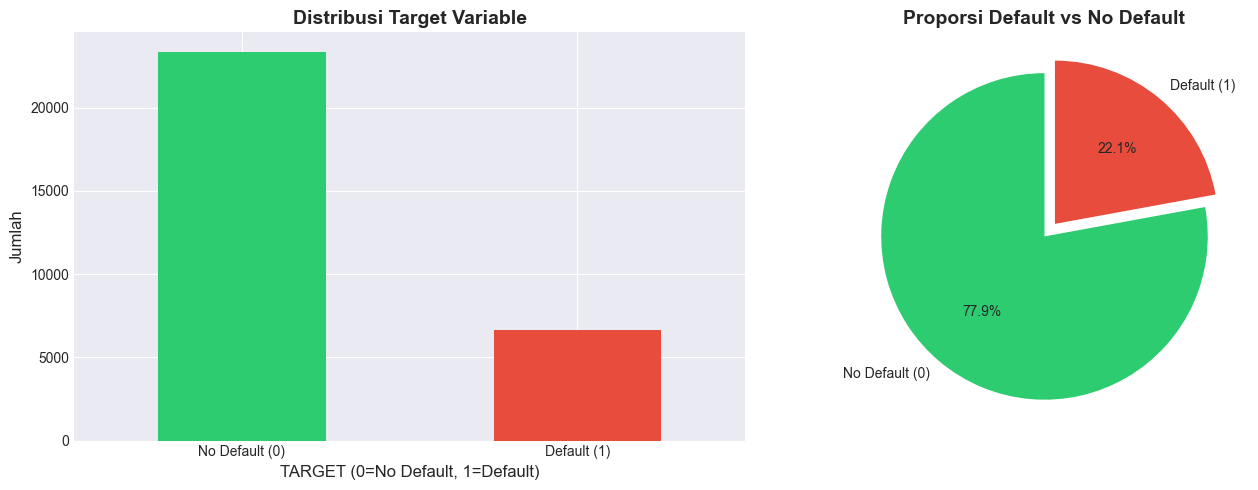


⚠️ Imbalance Ratio: 3.52:1
   Dataset TIDAK seimbang! Perlu diperhatikan saat evaluasi model.


In [9]:
# Visualisasi Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count Plot
target_dist.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Target Variable', fontsize=14, fontweight='bold')
axes[0].set_xlabel('TARGET (0=No Default, 1=Default)', fontsize=12)
axes[0].set_ylabel('Jumlah', fontsize=12)
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Pie Chart
axes[1].pie(target_dist, labels=['No Default (0)', 'Default (1)'], 
           autopct='%1.1f%%', startangle=90,
           colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[1].set_title('Proporsi Default vs No Default', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Cek Class Imbalance
imbalance_ratio = target_dist[0] / target_dist[1]
print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 2:
    print("   Dataset TIDAK seimbang! Perlu diperhatikan saat evaluasi model.")

## 1.2 Analisis Fitur-Fitur Penting

👥 ANALISIS FITUR DEMOGRAFIS


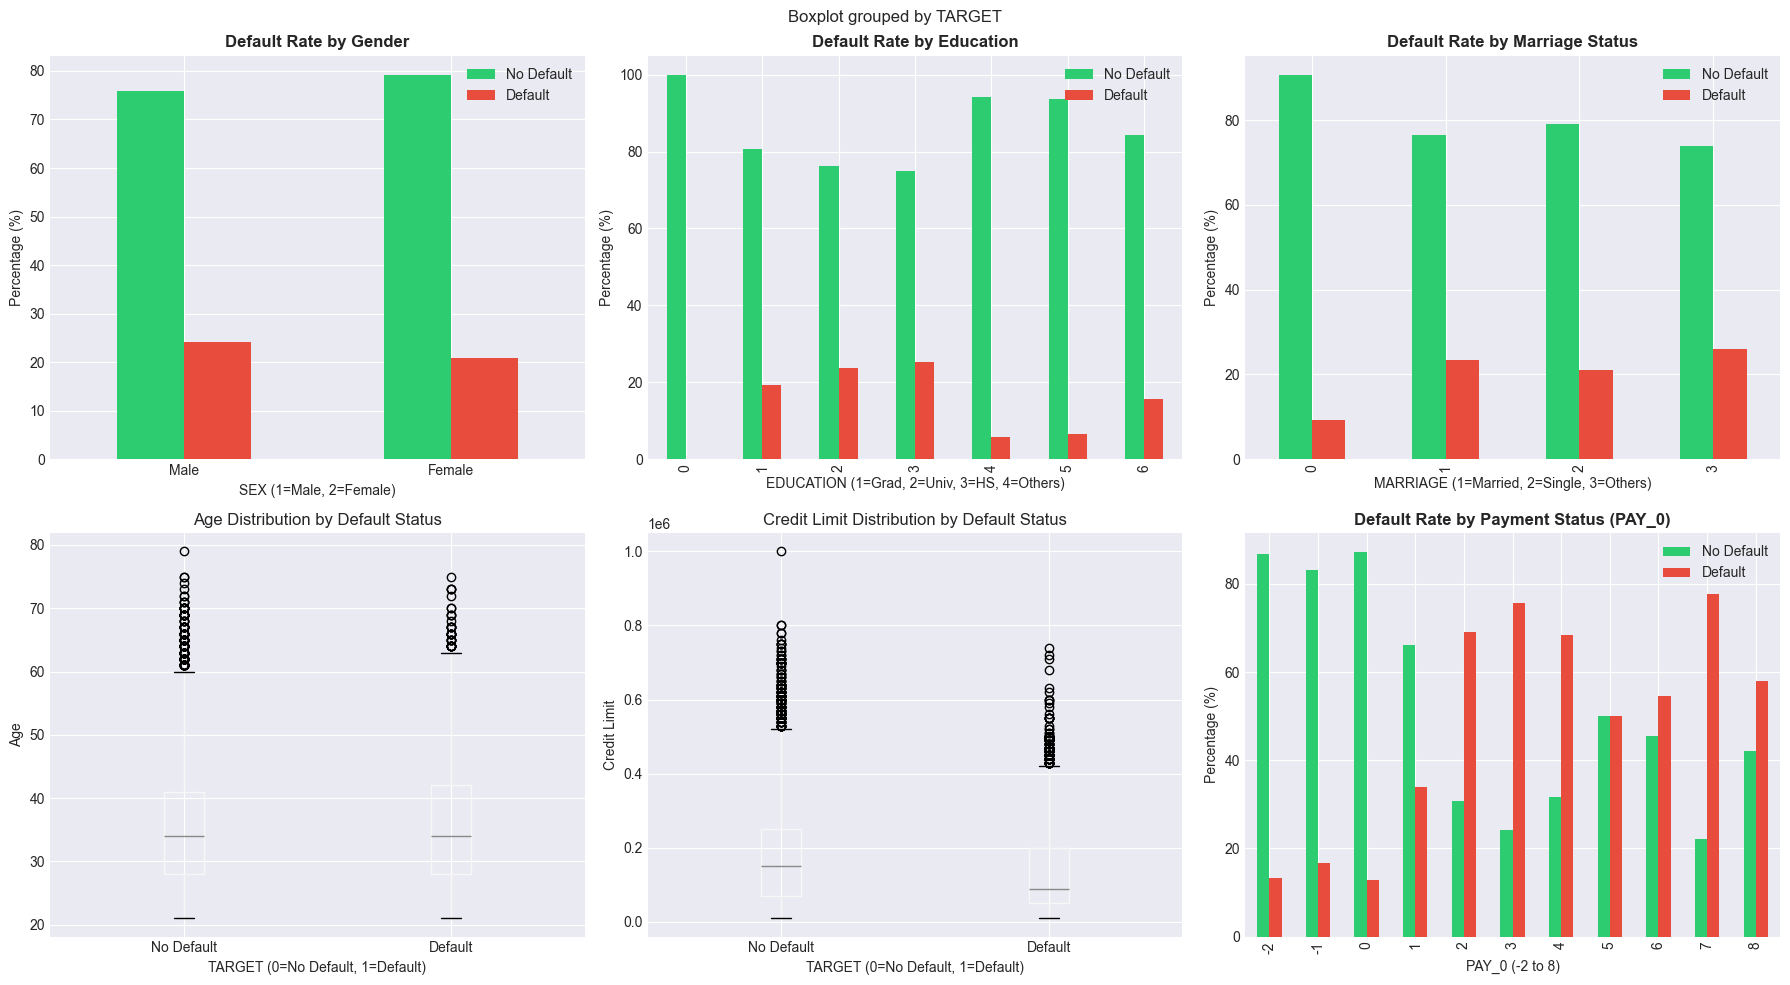


📊 Statistik Demografis per Target:

Rata-rata AGE:
TARGET
0    35.417266
1    35.725738
Name: AGE, dtype: float64

Rata-rata LIMIT_BAL:
TARGET
0    178099.726074
1    130109.656420
Name: LIMIT_BAL, dtype: float64


In [5]:
# ========================================
# ANALISIS FITUR DEMOGRAFIS
# ========================================

print("👥 ANALISIS FITUR DEMOGRAFIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Gender (SEX)
sex_default = pd.crosstab(df['SEX'], df['TARGET'], normalize='index') * 100
sex_default.plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Default Rate by Gender', fontweight='bold')
axes[0,0].set_xlabel('SEX (1=Male, 2=Female)')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].legend(['No Default', 'Default'])
axes[0,0].set_xticklabels(['Male', 'Female'], rotation=0)

# 2. Education
edu_default = pd.crosstab(df['EDUCATION'], df['TARGET'], normalize='index') * 100
edu_default.plot(kind='bar', ax=axes[0,1], color=['#2ecc71', '#e74c3c'])
axes[0,1].set_title('Default Rate by Education', fontweight='bold')
axes[0,1].set_xlabel('EDUCATION (1=Grad, 2=Univ, 3=HS, 4=Others)')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].legend(['No Default', 'Default'])

# 3. Marriage
mar_default = pd.crosstab(df['MARRIAGE'], df['TARGET'], normalize='index') * 100
mar_default.plot(kind='bar', ax=axes[0,2], color=['#2ecc71', '#e74c3c'])
axes[0,2].set_title('Default Rate by Marriage Status', fontweight='bold')
axes[0,2].set_xlabel('MARRIAGE (1=Married, 2=Single, 3=Others)')
axes[0,2].set_ylabel('Percentage (%)')
axes[0,2].legend(['No Default', 'Default'])

# 4. Age Distribution
df.boxplot(column='AGE', by='TARGET', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Default Status')
axes[1,0].set_xlabel('TARGET (0=No Default, 1=Default)')
axes[1,0].set_ylabel('Age')
plt.sca(axes[1,0])
plt.xticks([1, 2], ['No Default', 'Default'])

# 5. Credit Limit Distribution
df.boxplot(column='LIMIT_BAL', by='TARGET', ax=axes[1,1])
axes[1,1].set_title('Credit Limit Distribution by Default Status')
axes[1,1].set_xlabel('TARGET (0=No Default, 1=Default)')
axes[1,1].set_ylabel('Credit Limit')
plt.sca(axes[1,1])
plt.xticks([1, 2], ['No Default', 'Default'])

# 6. Payment Status Distribution (PAY_0)
pay_default = pd.crosstab(df['PAY_0'], df['TARGET'], normalize='index') * 100
pay_default.plot(kind='bar', ax=axes[1,2], color=['#2ecc71', '#e74c3c'])
axes[1,2].set_title('Default Rate by Payment Status (PAY_0)', fontweight='bold')
axes[1,2].set_xlabel('PAY_0 (-2 to 8)')
axes[1,2].set_ylabel('Percentage (%)')
axes[1,2].legend(['No Default', 'Default'])

plt.tight_layout()
plt.show()

# Statistik per Target
print("\n📊 Statistik Demografis per Target:")
print("\nRata-rata AGE:")
print(df.groupby('TARGET')['AGE'].mean())
print("\nRata-rata LIMIT_BAL:")
print(df.groupby('TARGET')['LIMIT_BAL'].mean())

## 1.3 Correlation Analysis

🔗 KORELASI FITUR DENGAN TARGET

Top 10 Fitur dengan Korelasi Tertinggi:
TARGET       1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
Name: TARGET, dtype: float64

Top 10 Fitur dengan Korelasi Terendah:
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: TARGET, dtype: float64


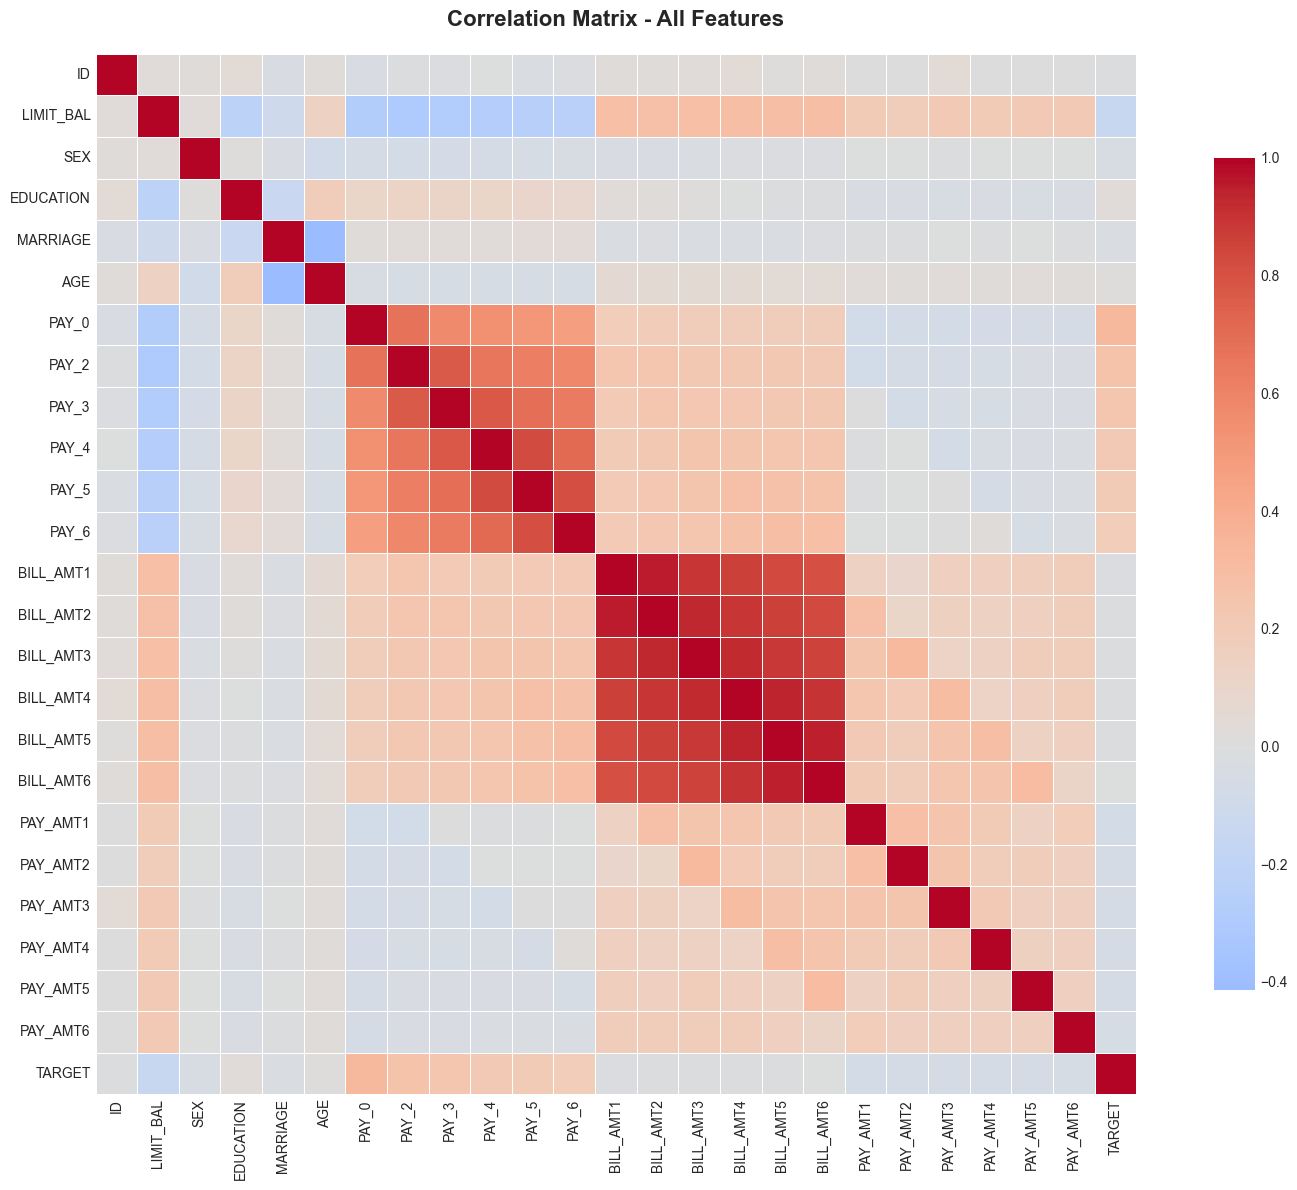

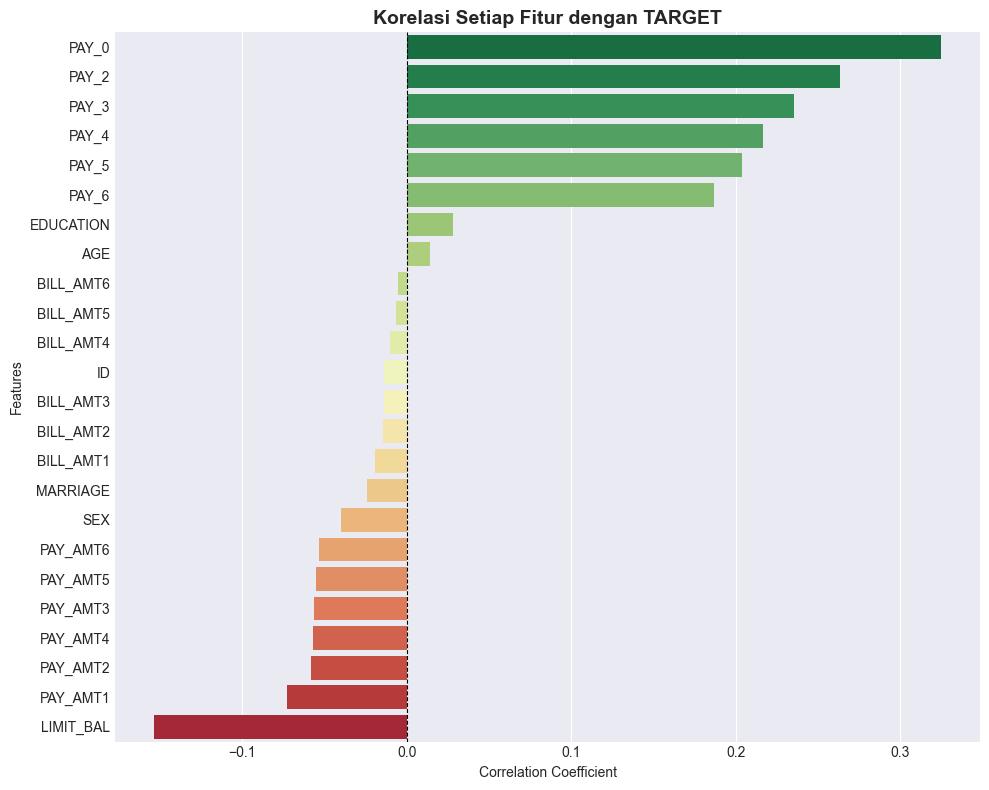

In [6]:
# ========================================
# CORRELATION MATRIX
# ========================================

# Hitung korelasi dengan target
correlation_with_target = df.corr()['TARGET'].sort_values(ascending=False)

print("🔗 KORELASI FITUR DENGAN TARGET")
print("="*60)
print("\nTop 10 Fitur dengan Korelasi Tertinggi:")
print(correlation_with_target.head(11))  # 11 karena termasuk TARGET sendiri

print("\nTop 10 Fitur dengan Korelasi Terendah:")
print(correlation_with_target.tail(10))

# Visualisasi Correlation Matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
           square=True, linewidths=0.5, annot=False, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Heatmap korelasi dengan TARGET saja
plt.figure(figsize=(10, 8))
target_corr = correlation_with_target.drop('TARGET').sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index, palette='RdYlGn_r')
plt.title('Korelasi Setiap Fitur dengan TARGET', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

---
# 🔧 BAGIAN 2: DATA PREPROCESSING
---

In [7]:
# ========================================
# PREPROCESSING - SPLIT DATA & SCALING
# ========================================

print("🔧 DATA PREPROCESSING")
print("="*60)

# 1. Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['TARGET', 'ID'])  # ID tidak digunakan untuk prediksi
y = df['TARGET']

print(f"\n1️⃣ Fitur (X) shape: {X.shape}")
print(f"   Target (y) shape: {y.shape}")
print(f"\n   Fitur yang digunakan: {X.shape[1]} fitur")
print(f"   Jumlah sampel: {X.shape[0]} sampel")

# 2. Split Data: 80% Training, 20% Testing
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n2️⃣ Data Split (80-20):")
print(f"   Training set: {X_train_raw.shape[0]} samples")
print(f"   Testing set: {X_test_raw.shape[0]} samples")

# Cek distribusi target setelah split
print(f"\n   Distribusi TARGET di Training Set:")
print(f"   {y_train.value_counts()}")
print(f"   {y_train.value_counts(normalize=True) * 100}")

# 3. Feature Scaling (StandardScaler)
# PENTING untuk SVM karena sensitif terhadap skala data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\n3️⃣ Feature Scaling (StandardScaler):")
print(f"   ✅ Data berhasil di-scale!")
print(f"\n   Contoh scaling pada 5 fitur pertama (row pertama):")
print(f"   Before: {X_train_raw.iloc[0, :5].values}")
print(f"   After:  {X_train[0, :5]}")

# Simpan untuk digunakan di clustering nanti
X_scaled_full = scaler.fit_transform(X)

print("\n✅ Preprocessing selesai!")

🔧 DATA PREPROCESSING

1️⃣ Fitur (X) shape: (30000, 23)
   Target (y) shape: (30000,)

   Fitur yang digunakan: 23 fitur
   Jumlah sampel: 30000 sampel

2️⃣ Data Split (80-20):
   Training set: 24000 samples
   Testing set: 6000 samples

   Distribusi TARGET di Training Set:
   TARGET
0    18691
1     5309
Name: count, dtype: int64
   TARGET
0    77.879167
1    22.120833
Name: proportion, dtype: float64

3️⃣ Feature Scaling (StandardScaler):
   ✅ Data berhasil di-scale!

   Contoh scaling pada 5 fitur pertama (row pertama):
   Before: [160000      2      2      2     33]
   After:  [-0.05686623  0.80844039  0.18452304  0.85673912 -0.26455769]

✅ Preprocessing selesai!


---
# 🤖 BAGIAN 3: KLASIFIKASI DENGAN SUPPORT VECTOR MACHINE (SVM)
---

## 3.1 Training Model SVM dengan Berbagai Kernel

In [8]:
# ========================================
# TRAINING SVM DENGAN BERBAGAI KERNEL
# ========================================

print("🤖 TRAINING MODEL SVM")
print("="*60)
print("\n⏳ Training model dengan 3 kernel berbeda...")
print("   (Ini memakan waktu beberapa menit karena data 24k+ rows)\n")

# Dictionary untuk menyimpan hasil
svm_results = {}
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:
    print(f"🔄 Training SVM dengan kernel '{kernel}'...")
    
    # Inisialisasi model
    svm_model = SVC(kernel=kernel, random_state=42, probability=True)
    
    # Training
    svm_model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = svm_model.predict(X_test)
    y_pred_proba = svm_model.predict_proba(X_test)[:, 1]
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred_proba)
    
    # Simpan hasil
    svm_results[kernel] = {
        'model': svm_model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    
    print(f"   ✅ {kernel.upper()} - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}\n")

print("\n✅ Training selesai untuk semua kernel!")

# Tampilkan perbandingan
print("\n" + "="*60)
print("📊 PERBANDINGAN PERFORMA SEMUA KERNEL")
print("="*60)

comparison_df = pd.DataFrame({
    'Kernel': kernels,
    'Accuracy': [svm_results[k]['accuracy'] for k in kernels],
    'Precision': [svm_results[k]['precision'] for k in kernels],
    'Recall': [svm_results[k]['recall'] for k in kernels],
    'F1-Score': [svm_results[k]['f1_score'] for k in kernels],
    'ROC-AUC': [svm_results[k]['roc_auc'] for k in kernels]
})

display(comparison_df)

# Tentukan kernel terbaik berdasarkan F1-Score
best_kernel = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Kernel']
print(f"\n🏆 Kernel Terbaik: {best_kernel.upper()} (F1-Score tertinggi)")

# Simpan model terbaik
best_model = svm_results[best_kernel]['model']
best_predictions = svm_results[best_kernel]['predictions']

🤖 TRAINING MODEL SVM

⏳ Training model dengan 3 kernel berbeda...
   (Ini memakan waktu beberapa menit karena data 24k+ rows)

🔄 Training SVM dengan kernel 'linear'...
   ✅ LINEAR - Accuracy: 0.8080, F1-Score: 0.3614

🔄 Training SVM dengan kernel 'rbf'...
   ✅ LINEAR - Accuracy: 0.8080, F1-Score: 0.3614

🔄 Training SVM dengan kernel 'rbf'...
   ✅ RBF - Accuracy: 0.8160, F1-Score: 0.4486

🔄 Training SVM dengan kernel 'poly'...
   ✅ RBF - Accuracy: 0.8160, F1-Score: 0.4486

🔄 Training SVM dengan kernel 'poly'...
   ✅ POLY - Accuracy: 0.8073, F1-Score: 0.3563


✅ Training selesai untuk semua kernel!

📊 PERBANDINGAN PERFORMA SEMUA KERNEL
   ✅ POLY - Accuracy: 0.8073, F1-Score: 0.3563


✅ Training selesai untuk semua kernel!

📊 PERBANDINGAN PERFORMA SEMUA KERNEL


,Kernel,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,linear,0.808000,0.683438,0.245667,0.361419,0.689807
1,rbf,0.816000,0.665185,0.338357,0.448551,0.721000
2,poly,0.807333,0.682303,0.241145,0.356347,0.700143



🏆 Kernel Terbaik: RBF (F1-Score tertinggi)


## 3.2 Visualisasi Performa Model SVM

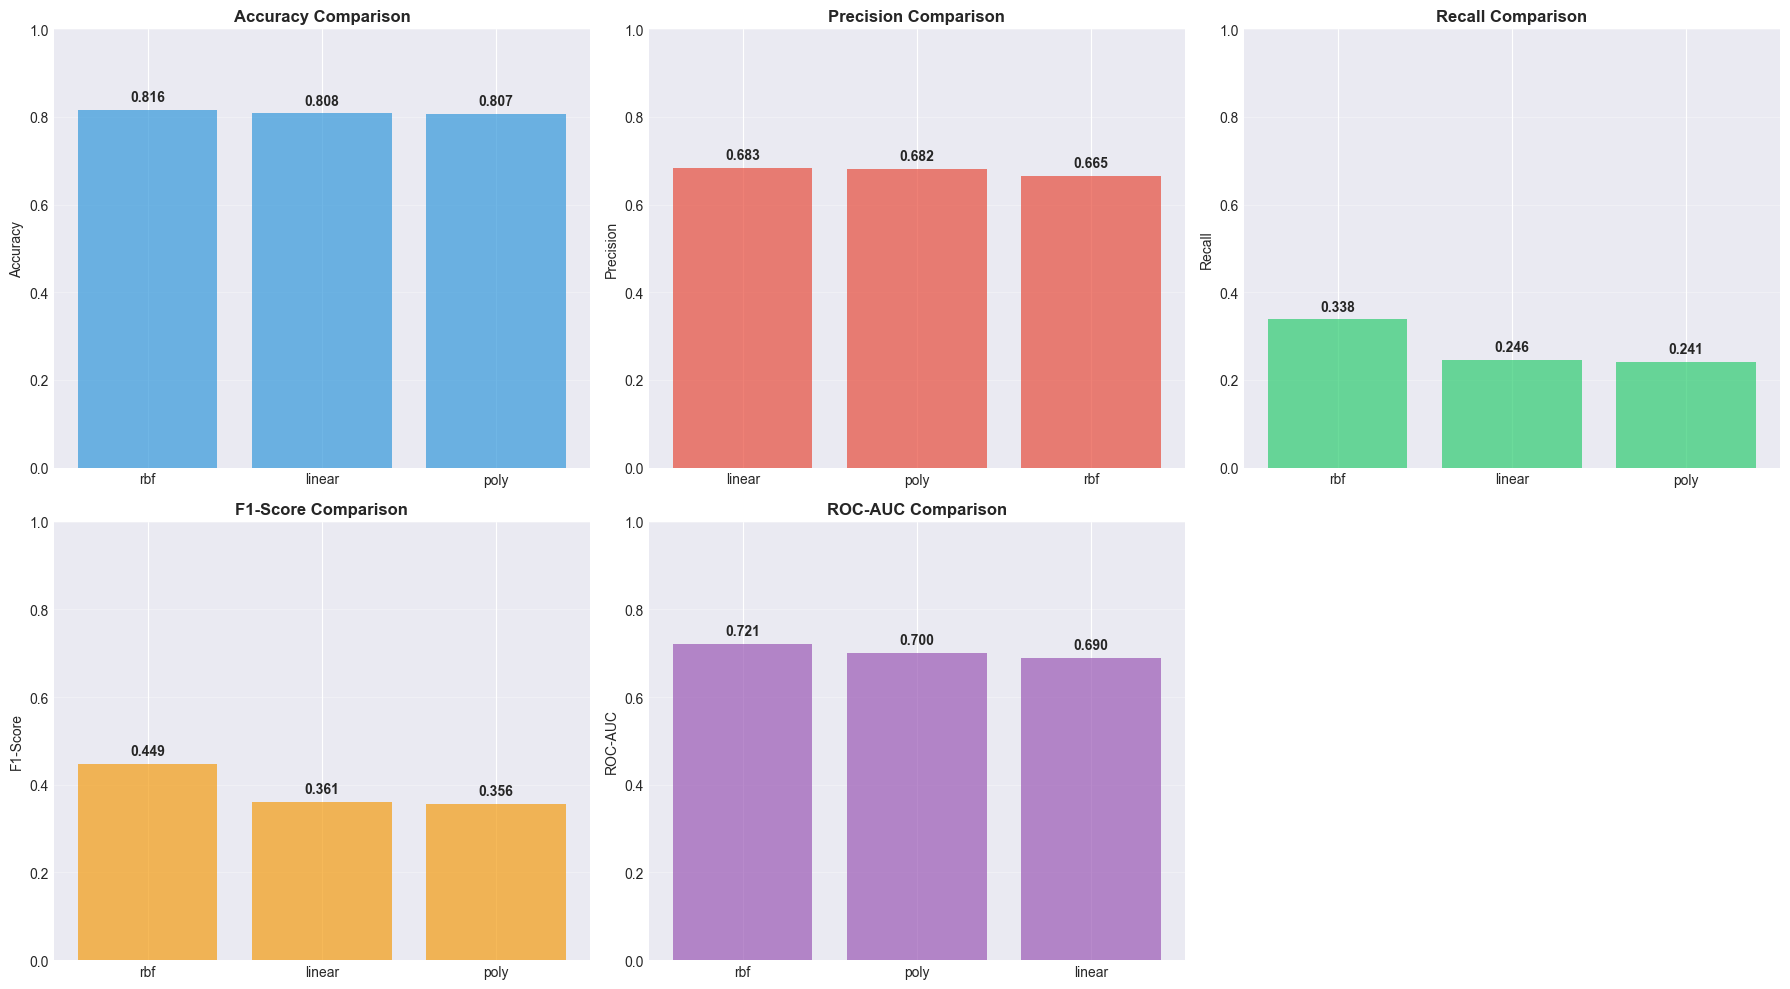

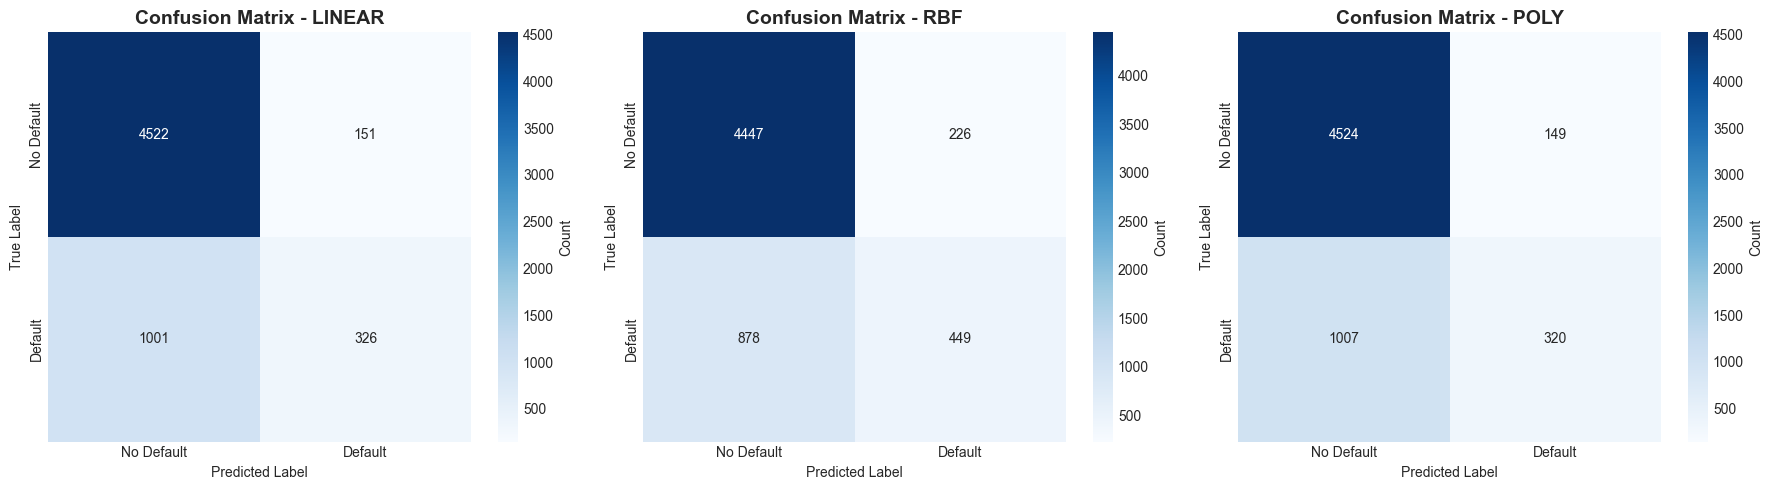

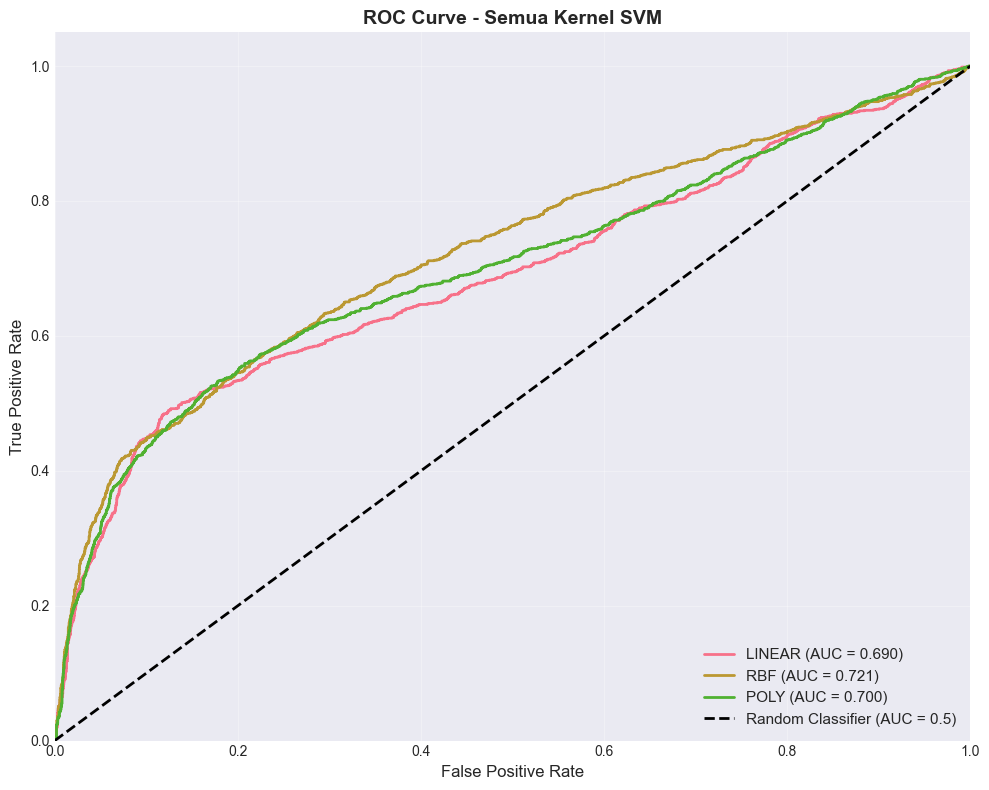


✅ Visualisasi performa SVM selesai!


In [9]:
# ========================================
# VISUALISASI PERFORMA SVM
# ========================================

# 1. Bar Chart Perbandingan Metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    
    data = comparison_df[['Kernel', metric]].sort_values(metric, ascending=False)
    axes[row, col].bar(data['Kernel'], data[metric], color=colors[idx], alpha=0.7)
    axes[row, col].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[row, col].set_ylabel(metric)
    axes[row, col].set_ylim([0, 1])
    axes[row, col].grid(axis='y', alpha=0.3)
    
    # Tambahkan nilai di atas bar
    for i, v in enumerate(data[metric]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Hide last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# 2. Confusion Matrix untuk semua kernel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, kernel in enumerate(kernels):
    cm = svm_results[kernel]['confusion_matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
               cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'Confusion Matrix - {kernel.upper()}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xticklabels(['No Default', 'Default'])
    axes[idx].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

# 3. ROC Curve untuk semua kernel
plt.figure(figsize=(10, 8))

for kernel in kernels:
    y_proba = svm_results[kernel]['probabilities']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = svm_results[kernel]['roc_auc']
    
    plt.plot(fpr, tpr, lw=2, label=f'{kernel.upper()} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Semua Kernel SVM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Visualisasi performa SVM selesai!")

## 3.3 Classification Report Model Terbaik

In [10]:
# ========================================
# DETAILED REPORT MODEL TERBAIK
# ========================================

print("="*60)
print(f"📊 CLASSIFICATION REPORT - MODEL TERBAIK: {best_kernel.upper()}")
print("="*60)

# Classification Report
print("\n" + classification_report(y_test, best_predictions, 
                                   target_names=['No Default (0)', 'Default (1)']))

# Confusion Matrix Detail
cm = svm_results[best_kernel]['confusion_matrix']
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*60)
print("CONFUSION MATRIX BREAKDOWN")
print("="*60)
print(f"True Negatives (TN):  {tn:5d}  ← Correctly predicted No Default")
print(f"False Positives (FP): {fp:5d}  ← Incorrectly predicted as Default")
print(f"False Negatives (FN): {fn:5d}  ← Incorrectly predicted as No Default")
print(f"True Positives (TP):  {tp:5d}  ← Correctly predicted Default")

# Metrics Detail
print("\n" + "="*60)
print("DETAILED METRICS")
print("="*60)
print(f"Accuracy:  {svm_results[best_kernel]['accuracy']:.4f}")
print(f"Precision: {svm_results[best_kernel]['precision']:.4f}  ← Dari yang diprediksi Default, berapa yang benar?")
print(f"Recall:    {svm_results[best_kernel]['recall']:.4f}  ← Dari yang benar-benar Default, berapa yang tertangkap?")
print(f"F1-Score:  {svm_results[best_kernel]['f1_score']:.4f}  ← Harmonic mean dari Precision & Recall")
print(f"ROC-AUC:   {svm_results[best_kernel]['roc_auc']:.4f}  ← Kemampuan model membedakan kelas")

# Interpretasi
print("\n" + "="*60)
print("💡 INTERPRETASI HASIL")
print("="*60)
accuracy = svm_results[best_kernel]['accuracy']
if accuracy >= 0.85:
    print("✅ Model memiliki akurasi SANGAT BAIK (>85%)")
elif accuracy >= 0.75:
    print("✅ Model memiliki akurasi BAIK (75-85%)")
elif accuracy >= 0.65:
    print("⚠️  Model memiliki akurasi CUKUP (65-75%)")
else:
    print("❌ Model memiliki akurasi KURANG (< 65%)")

recall = svm_results[best_kernel]['recall']
if recall >= 0.7:
    print(f"✅ Model dapat menangkap {recall*100:.1f}% dari kasus Default (Recall tinggi)")
else:
    print(f"⚠️  Model hanya menangkap {recall*100:.1f}% dari kasus Default (Recall rendah)")
    
print(f"\n📌 Model ini cocok untuk: Prediksi risiko default kartu kredit")
print(f"   dengan tingkat kepercayaan {accuracy*100:.1f}%")

📊 CLASSIFICATION REPORT - MODEL TERBAIK: RBF

                precision    recall  f1-score   support

No Default (0)       0.84      0.95      0.89      4673
   Default (1)       0.67      0.34      0.45      1327

      accuracy                           0.82      6000
     macro avg       0.75      0.64      0.67      6000
  weighted avg       0.80      0.82      0.79      6000


CONFUSION MATRIX BREAKDOWN
True Negatives (TN):   4447  ← Correctly predicted No Default
False Positives (FP):   226  ← Incorrectly predicted as Default
False Negatives (FN):   878  ← Incorrectly predicted as No Default
True Positives (TP):    449  ← Correctly predicted Default

DETAILED METRICS
Accuracy:  0.8160
Precision: 0.6652  ← Dari yang diprediksi Default, berapa yang benar?
Recall:    0.3384  ← Dari yang benar-benar Default, berapa yang tertangkap?
F1-Score:  0.4486  ← Harmonic mean dari Precision & Recall
ROC-AUC:   0.7210  ← Kemampuan model membedakan kelas

💡 INTERPRETASI HASIL
✅ Model memiliki a

---
# 🎯 BAGIAN 5: CLUSTERING DENGAN K-MEANS
---

**Catatan Penting:** Sesuai instruksi, kolom label/TARGET dihapus sebelum clustering (unsupervised learning)

## 5.1 Elbow Method untuk Menentukan Jumlah Cluster Optimal

🎯 CLUSTERING: MENENTUKAN JUMLAH CLUSTER OPTIMAL

📌 Sesuai instruksi: Menghapus kolom label/TARGET dari dataset
   Shape data untuk clustering: (30000, 23)
   Fitur yang digunakan: 23 fitur
   Jumlah sampel: 30000 sampel

⏳ Menghitung Elbow Method & Silhouette Score...
   (Proses ini memakan waktu 1-2 menit)

   Testing k=2... WCSS: 568494, Silhouette: 0.3426
   Testing k=3... WCSS: 568494, Silhouette: 0.3426
   Testing k=3... WCSS: 488251, Silhouette: 0.1875
   Testing k=4... WCSS: 488251, Silhouette: 0.1875
   Testing k=4... WCSS: 458033, Silhouette: 0.1600
   Testing k=5... WCSS: 458033, Silhouette: 0.1600
   Testing k=5... WCSS: 434173, Silhouette: 0.1584
   Testing k=6... WCSS: 434173, Silhouette: 0.1584
   Testing k=6... WCSS: 413708, Silhouette: 0.1650
   Testing k=7... WCSS: 413708, Silhouette: 0.1650
   Testing k=7... WCSS: 397212, Silhouette: 0.1411
   Testing k=8... WCSS: 397212, Silhouette: 0.1411
   Testing k=8... WCSS: 383407, Silhouette: 0.1402
   Testing k=9... WCSS: 383

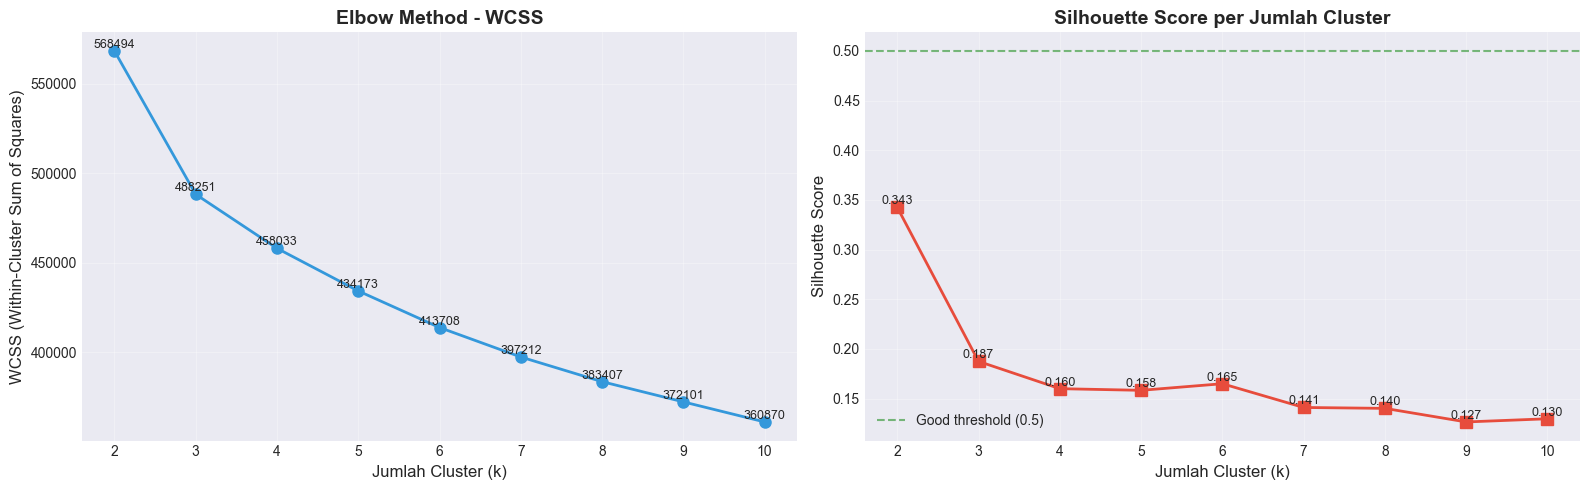


💡 REKOMENDASI JUMLAH CLUSTER OPTIMAL

📌 Berdasarkan Silhouette Score tertinggi: k = 2
   Silhouette Score = 0.3426

📌 Berdasarkan Elbow Method:
   Lihat grafik di atas - pilih k di mana penurunan WCSS mulai melambat
   Biasanya di k=3 atau k=4 (terlihat 'siku' pada grafik)

✅ Untuk analisis selanjutnya, kita gunakan k=3


In [11]:
# ========================================
# ELBOW METHOD - MENENTUKAN K OPTIMAL
# ========================================

print("🎯 CLUSTERING: MENENTUKAN JUMLAH CLUSTER OPTIMAL")
print("="*60)

# PENTING: Hapus kolom TARGET dan ID untuk clustering (sesuai instruksi)
print("\n📌 Sesuai instruksi: Menghapus kolom label/TARGET dari dataset")
X_clustering = X_scaled_full  # Data sudah di-scale dari preprocessing, tanpa TARGET & ID

print(f"   Shape data untuk clustering: {X_clustering.shape}")
print(f"   Fitur yang digunakan: {X_clustering.shape[1]} fitur")
print(f"   Jumlah sampel: {X_clustering.shape[0]} sampel")

# Hitung WCSS (Within-Cluster Sum of Squares) untuk berbagai k
wcss = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Test k=2 sampai k=10

print("\n⏳ Menghitung Elbow Method & Silhouette Score...")
print("   (Proses ini memakan waktu 1-2 menit)\n")

for k in range_n_clusters:
    print(f"   Testing k={k}...", end=" ")
    
    # Inisialisasi dan fit K-Means
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    
    # Simpan WCSS (inertia)
    wcss.append(kmeans.inertia_)
    
    # Hitung Silhouette Score (sample 5000 data untuk efisiensi)
    sample_size = min(5000, X_clustering.shape[0])
    sample_idx = np.random.choice(X_clustering.shape[0], sample_size, replace=False)
    sil_score = silhouette_score(X_clustering[sample_idx], kmeans.labels_[sample_idx])
    silhouette_scores.append(sil_score)
    
    print(f"WCSS: {kmeans.inertia_:.0f}, Silhouette: {sil_score:.4f}")

print("\n✅ Perhitungan selesai!")

# Visualisasi Elbow Method & Silhouette Score
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Elbow Method (WCSS)
axes[0].plot(range_n_clusters, wcss, marker='o', linestyle='-', 
            linewidth=2, markersize=8, color='#3498db')
axes[0].set_title('Elbow Method - WCSS', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Tandai nilai di setiap titik
for i, (k, w) in enumerate(zip(range_n_clusters, wcss)):
    axes[0].text(k, w, f'{w:.0f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Silhouette Score
axes[1].plot(range_n_clusters, silhouette_scores, marker='s', linestyle='-', 
            linewidth=2, markersize=8, color='#e74c3c')
axes[1].set_title('Silhouette Score per Jumlah Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Good threshold (0.5)')
axes[1].legend()

# Tandai nilai di setiap titik
for i, (k, s) in enumerate(zip(range_n_clusters, silhouette_scores)):
    axes[1].text(k, s, f'{s:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Rekomendasi k optimal
print("\n" + "="*60)
print("💡 REKOMENDASI JUMLAH CLUSTER OPTIMAL")
print("="*60)

# Cari k dengan silhouette score tertinggi
optimal_k_silhouette = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\n📌 Berdasarkan Silhouette Score tertinggi: k = {optimal_k_silhouette}")
print(f"   Silhouette Score = {max(silhouette_scores):.4f}")

print(f"\n📌 Berdasarkan Elbow Method:")
print(f"   Lihat grafik di atas - pilih k di mana penurunan WCSS mulai melambat")
print(f"   Biasanya di k=3 atau k=4 (terlihat 'siku' pada grafik)")

print(f"\n✅ Untuk analisis selanjutnya, kita gunakan k=3")

## 5.2 Implementasi K-Means Clustering

🎯 IMPLEMENTASI K-MEANS CLUSTERING

⏳ Melatih K-Means dengan k=3...
✅ K-Means training selesai!
   Jumlah iterasi: 14
   Final inertia: 488250.73

📊 EVALUASI KUALITAS CLUSTERING

1️⃣ Silhouette Score: 0.1847
   Range: [-1, 1], Optimal: mendekati 1
   Interpretasi: POOR - Struktur cluster lemah

2️⃣ Davies-Bouldin Score: 1.6673
   Range: [0, ∞), Optimal: mendekati 0
   Interpretasi: Semakin rendah semakin baik

3️⃣ Calinski-Harabasz Score: 6197.51
   Range: [0, ∞), Optimal: semakin tinggi semakin baik

📈 DISTRIBUSI DATA PER CLUSTER

Jumlah data per cluster:
Cluster
0    15872
1    10543
2     3585
Name: count, dtype: int64

Persentase:
Cluster
0    52.906667
1    35.143333
2    11.950000
Name: proportion, dtype: float64

1️⃣ Silhouette Score: 0.1847
   Range: [-1, 1], Optimal: mendekati 1
   Interpretasi: POOR - Struktur cluster lemah

2️⃣ Davies-Bouldin Score: 1.6673
   Range: [0, ∞), Optimal: mendekati 0
   Interpretasi: Semakin rendah semakin baik

3️⃣ Calinski-Harabasz Score: 6197.51

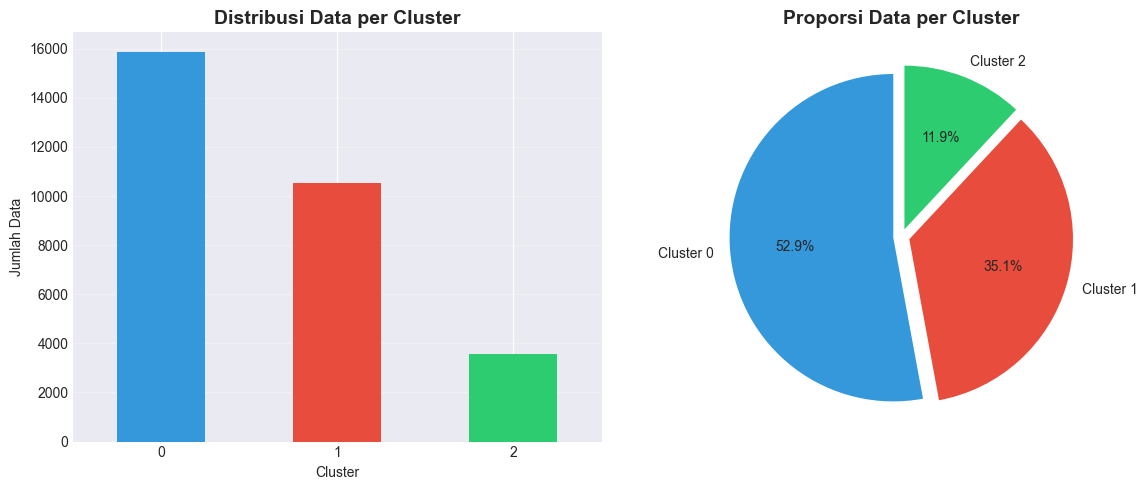


✅ Clustering selesai!


In [12]:
# ========================================
# IMPLEMENTASI K-MEANS CLUSTERING
# ========================================

print("🎯 IMPLEMENTASI K-MEANS CLUSTERING")
print("="*60)

# Gunakan k=3 (bisa disesuaikan dengan hasil Elbow Method)
k_optimal = 3

print(f"\n⏳ Melatih K-Means dengan k={k_optimal}...")

# Inisialisasi dan training K-Means
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', 
                     random_state=42, n_init=10, max_iter=300)

# Fit dan prediksi cluster
cluster_labels = kmeans_final.fit_predict(X_clustering)

print(f"✅ K-Means training selesai!")
print(f"   Jumlah iterasi: {kmeans_final.n_iter_}")
print(f"   Final inertia: {kmeans_final.inertia_:.2f}")

# Tambahkan hasil clustering ke dataframe original
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# EVALUASI KUALITAS CLUSTERING
print("\n" + "="*60)
print("📊 EVALUASI KUALITAS CLUSTERING")
print("="*60)

# 1. Silhouette Score (sample untuk efisiensi)
sample_size = min(10000, X_clustering.shape[0])
sample_idx = np.random.choice(X_clustering.shape[0], sample_size, replace=False)
sil_score = silhouette_score(X_clustering[sample_idx], cluster_labels[sample_idx])

# 2. Davies-Bouldin Score (semakin rendah semakin baik)
db_score = davies_bouldin_score(X_clustering, cluster_labels)

# 3. Calinski-Harabasz Score (semakin tinggi semakin baik)
ch_score = calinski_harabasz_score(X_clustering, cluster_labels)

print(f"\n1️⃣ Silhouette Score: {sil_score:.4f}")
print(f"   Range: [-1, 1], Optimal: mendekati 1")
print(f"   Interpretasi: ", end="")
if sil_score > 0.7:
    print("EXCELLENT - Cluster sangat terpisah dengan baik")
elif sil_score > 0.5:
    print("GOOD - Struktur cluster yang reasonable")
elif sil_score > 0.25:
    print("FAIR - Ada overlap antar cluster")
else:
    print("POOR - Struktur cluster lemah")

print(f"\n2️⃣ Davies-Bouldin Score: {db_score:.4f}")
print(f"   Range: [0, ∞), Optimal: mendekati 0")
print(f"   Interpretasi: Semakin rendah semakin baik")

print(f"\n3️⃣ Calinski-Harabasz Score: {ch_score:.2f}")
print(f"   Range: [0, ∞), Optimal: semakin tinggi semakin baik")

# DISTRIBUSI DATA PER CLUSTER
print("\n" + "="*60)
print("📈 DISTRIBUSI DATA PER CLUSTER")
print("="*60)

cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print("\nJumlah data per cluster:")
print(cluster_counts)
print(f"\nPersentase:")
print(df_clustered['Cluster'].value_counts(normalize=True).sort_index() * 100)

# Visualisasi distribusi cluster
plt.figure(figsize=(12, 5))

# Bar chart
plt.subplot(1, 2, 1)
cluster_counts.plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Distribusi Data per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Pie chart
plt.subplot(1, 2, 2)
plt.pie(cluster_counts, labels=[f'Cluster {i}' for i in range(k_optimal)],
       autopct='%1.1f%%', startangle=90, colors=['#3498db', '#e74c3c', '#2ecc71'],
       explode=(0.05, 0.05, 0.05))
plt.title('Proporsi Data per Cluster', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Clustering selesai!")

## 5.3 Karakteristik & Profiling Setiap Cluster

🔍 ANALISIS KARAKTERISTIK SETIAP CLUSTER

📊 Rata-rata Nilai Fitur per Cluster:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
Cluster,,,,,,,,,,,,,,,,,,,,,
0,14932.048576,106144.279234,1.581779,1.982611,1.594821,34.517326,0.419481,0.459110,0.454637,0.389617,...,37005.705897,33971.799962,32691.764113,3774.204385,3598.490801,3070.774698,2871.230847,2932.004221,3133.996031,0.266129
1,14927.916817,220320.591862,1.647634,1.674950,1.503462,36.419899,-0.764488,-1.146448,-1.222992,-1.264915,...,6126.833729,6327.544627,6519.690885,4858.341459,5436.756616,5044.598596,4892.455658,4824.785071,5515.689652,0.164659
2,15517.014784,283672.993026,1.571827,1.803905,1.504045,37.023989,0.251325,0.219526,0.193026,0.148396,...,180178.158159,168320.869456,161375.740865,16396.582706,17628.991353,15298.718550,13285.626220,12992.231241,13548.222036,0.188563



👥 PROFIL DETAIL PER CLUSTER

🔹 CLUSTER 0 - 15872 nasabah (52.9%)

📌 Karakteristik Demografis:
   • Rata-rata Credit Limit: Rp 106,144
   • Rata-rata Umur: 34.5 tahun
   • Gender dominan: Female
   • Education dominan: 2 (1=Grad, 2=Univ, 3=HS, 4=Others)
   • Marriage dominan: 2 (1=Married, 2=Single, 3=Others)

💳 Pola Pembayaran:
   • Rata-rata Payment Status (PAY_0): 0.42
   • Rata-rata Bill Amount (BILL_AMT1): Rp 44,874
   • Rata-rata Payment Amount (PAY_AMT1): Rp 3,774

🎯 Default Status:
   • Default rate: 26.61%
   • Jumlah default: 4224 dari 15872 nasabah

🔹 CLUSTER 1 - 10543 nasabah (35.1%)

📌 Karakteristik Demografis:
   • Rata-rata Credit Limit: Rp 220,321
   • Rata-rata Umur: 36.4 tahun
   • Gender dominan: Female
   • Education dominan: 1 (1=Grad, 2=Univ, 3=HS, 4=Others)
   • Marriage dominan: 1 (1=Married, 2=Single, 3=Others)

💳 Pola Pembayaran:
   • Rata-rata Payment Status (PAY_0): -0.76
   • Rata-rata Bill Amount (BILL_AMT1): Rp 10,143
   • Rata-rata Payment Amount (PAY_AM

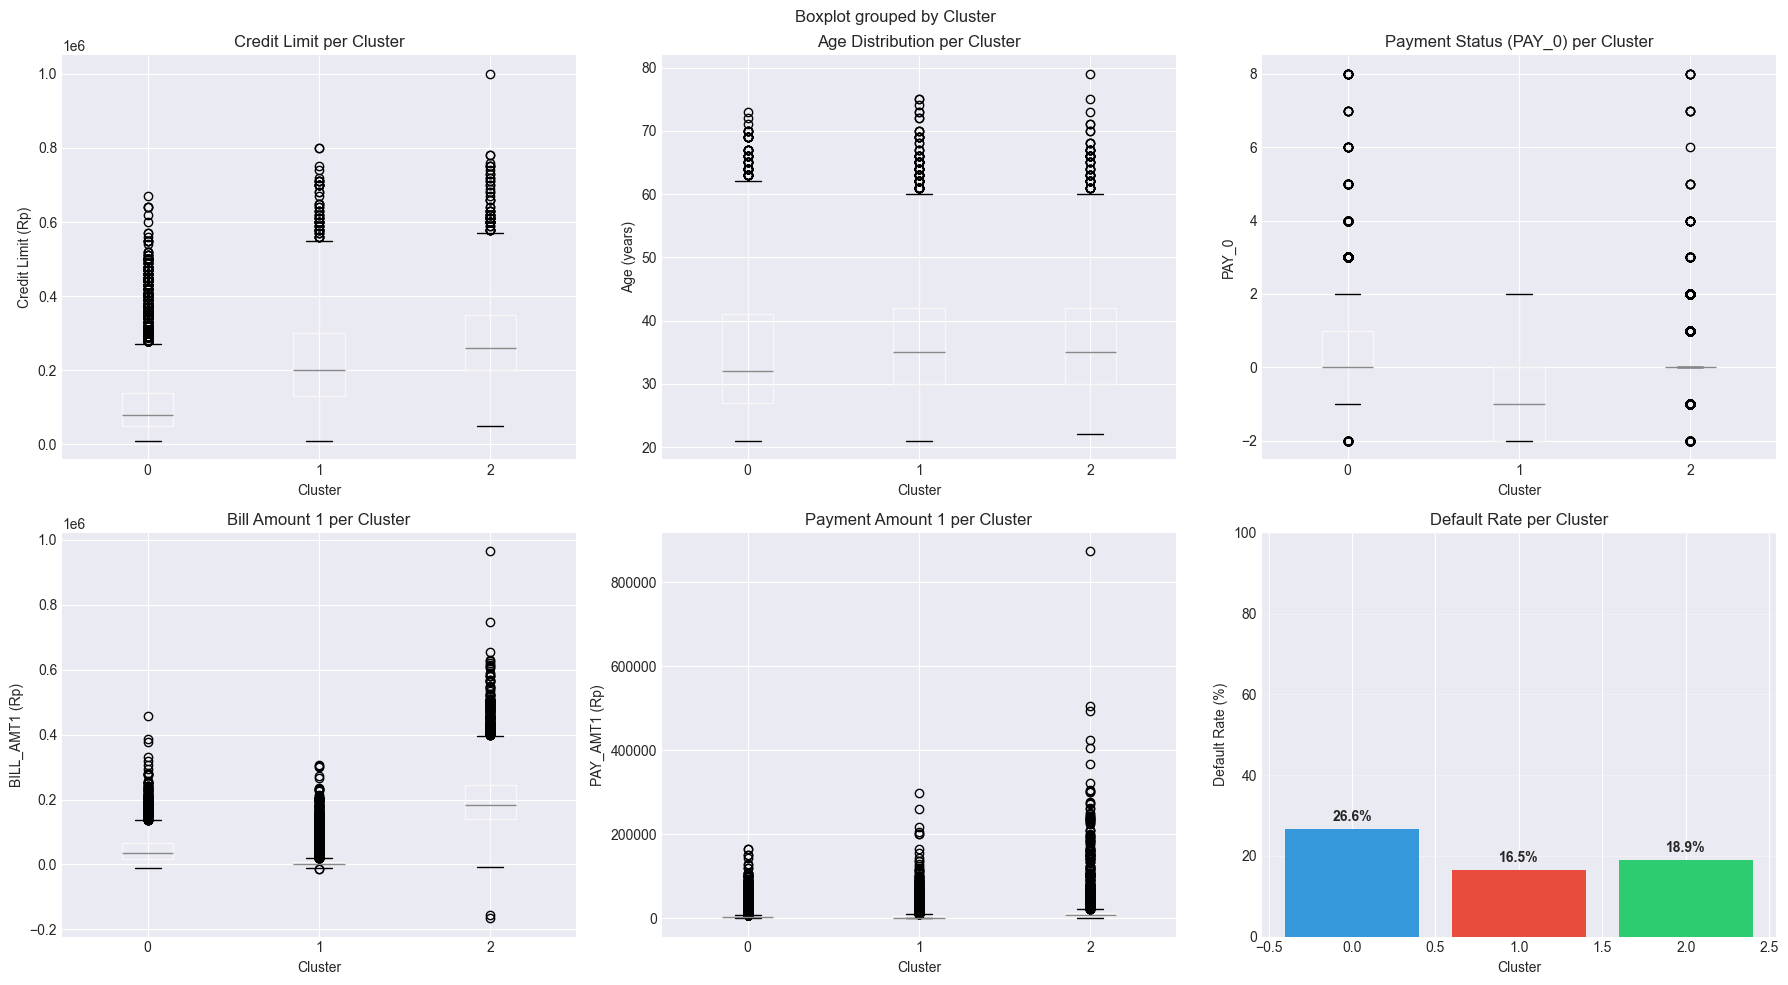


✅ Analisis karakteristik cluster selesai!


In [13]:
# ========================================
# KARAKTERISTIK SETIAP CLUSTER
# ========================================

print("🔍 ANALISIS KARAKTERISTIK SETIAP CLUSTER")
print("="*60)

# Analisis rata-rata fitur per cluster
cluster_profile = df_clustered.groupby('Cluster').mean()

print("\n📊 Rata-rata Nilai Fitur per Cluster:")
display(cluster_profile)

# PROFIL DETAIL SETIAP CLUSTER
print("\n" + "="*60)
print("👥 PROFIL DETAIL PER CLUSTER")
print("="*60)

for cluster_id in range(k_optimal):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    
    print(f"\n{'='*60}")
    print(f"🔹 CLUSTER {cluster_id} - {len(cluster_data)} nasabah ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    print(f"{'='*60}")
    
    print(f"\n📌 Karakteristik Demografis:")
    print(f"   • Rata-rata Credit Limit: Rp {cluster_data['LIMIT_BAL'].mean():,.0f}")
    print(f"   • Rata-rata Umur: {cluster_data['AGE'].mean():.1f} tahun")
    print(f"   • Gender dominan: {'Male' if cluster_data['SEX'].mode()[0] == 1 else 'Female'}")
    print(f"   • Education dominan: {cluster_data['EDUCATION'].mode()[0]} (1=Grad, 2=Univ, 3=HS, 4=Others)")
    print(f"   • Marriage dominan: {cluster_data['MARRIAGE'].mode()[0]} (1=Married, 2=Single, 3=Others)")
    
    print(f"\n💳 Pola Pembayaran:")
    print(f"   • Rata-rata Payment Status (PAY_0): {cluster_data['PAY_0'].mean():.2f}")
    print(f"   • Rata-rata Bill Amount (BILL_AMT1): Rp {cluster_data['BILL_AMT1'].mean():,.0f}")
    print(f"   • Rata-rata Payment Amount (PAY_AMT1): Rp {cluster_data['PAY_AMT1'].mean():,.0f}")
    
    # Analisis default rate per cluster (jika TARGET ada)
    if 'TARGET' in cluster_data.columns:
        default_rate = cluster_data['TARGET'].mean() * 100
        default_count = cluster_data['TARGET'].sum()
        print(f"\n🎯 Default Status:")
        print(f"   • Default rate: {default_rate:.2f}%")
        print(f"   • Jumlah default: {int(default_count)} dari {len(cluster_data)} nasabah")

# VISUALISASI PERBANDINGAN CLUSTER
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Credit Limit
df_clustered.boxplot(column='LIMIT_BAL', by='Cluster', ax=axes[0,0])
axes[0,0].set_title('Credit Limit per Cluster')
axes[0,0].set_ylabel('Credit Limit (Rp)')
plt.sca(axes[0,0])
plt.xlabel('Cluster')

# 2. Age
df_clustered.boxplot(column='AGE', by='Cluster', ax=axes[0,1])
axes[0,1].set_title('Age Distribution per Cluster')
axes[0,1].set_ylabel('Age (years)')
plt.sca(axes[0,1])
plt.xlabel('Cluster')

# 3. Payment Status (PAY_0)
df_clustered.boxplot(column='PAY_0', by='Cluster', ax=axes[0,2])
axes[0,2].set_title('Payment Status (PAY_0) per Cluster')
axes[0,2].set_ylabel('PAY_0')
plt.sca(axes[0,2])
plt.xlabel('Cluster')

# 4. Bill Amount 1
df_clustered.boxplot(column='BILL_AMT1', by='Cluster', ax=axes[1,0])
axes[1,0].set_title('Bill Amount 1 per Cluster')
axes[1,0].set_ylabel('BILL_AMT1 (Rp)')
plt.sca(axes[1,0])
plt.xlabel('Cluster')

# 5. Payment Amount 1
df_clustered.boxplot(column='PAY_AMT1', by='Cluster', ax=axes[1,1])
axes[1,1].set_title('Payment Amount 1 per Cluster')
axes[1,1].set_ylabel('PAY_AMT1 (Rp)')
plt.sca(axes[1,1])
plt.xlabel('Cluster')

# 6. Default Rate per Cluster
if 'TARGET' in df_clustered.columns:
    default_by_cluster = df_clustered.groupby('Cluster')['TARGET'].mean() * 100
    axes[1,2].bar(default_by_cluster.index, default_by_cluster.values, 
                 color=['#3498db', '#e74c3c', '#2ecc71'])
    axes[1,2].set_title('Default Rate per Cluster')
    axes[1,2].set_xlabel('Cluster')
    axes[1,2].set_ylabel('Default Rate (%)')
    axes[1,2].set_ylim([0, 100])
    axes[1,2].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(default_by_cluster.values):
        axes[1,2].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Analisis karakteristik cluster selesai!")

## 5.4 Visualisasi Cluster dengan PCA (2D & 3D)

🎨 VISUALISASI CLUSTER DENGAN PCA

⏳ Melakukan PCA untuk visualisasi...
✅ PCA 2D selesai!
   Explained Variance: 46.27%
✅ PCA 3D selesai!
   Explained Variance: 53.01%


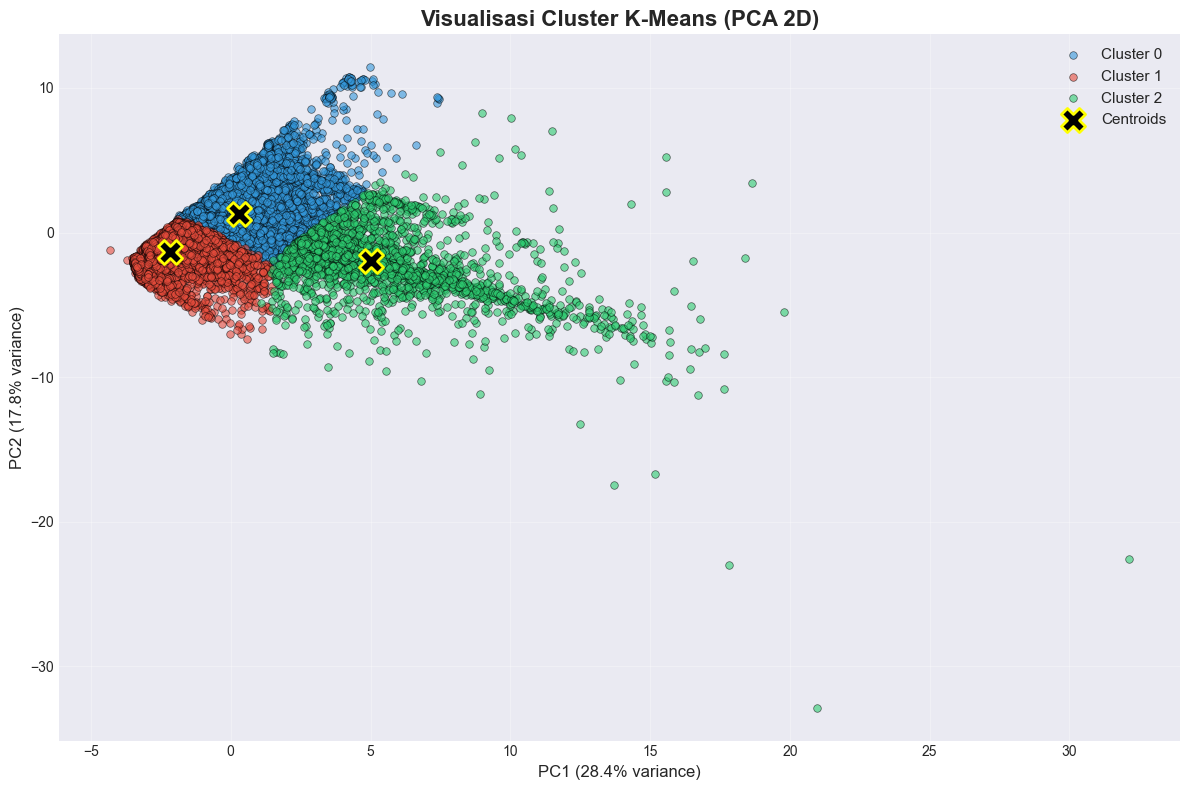


📊 Membuat visualisasi 3D interaktif...


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [16]:
# ========================================
# VISUALISASI CLUSTER DENGAN PCA
# ========================================

print("🎨 VISUALISASI CLUSTER DENGAN PCA")
print("="*60)

# PCA untuk reduksi dimensi ke 2D dan 3D
print("\n⏳ Melakukan PCA untuk visualisasi...")

# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_clustering)

print(f"✅ PCA 2D selesai!")
print(f"   Explained Variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_clustering)

print(f"✅ PCA 3D selesai!")
print(f"   Explained Variance: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

# VISUALISASI 2D
plt.figure(figsize=(12, 8))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

for cluster_id in range(k_optimal):
    cluster_points = X_pca_2d[cluster_labels == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
               c=colors[cluster_id], label=f'Cluster {cluster_id}',
               alpha=0.6, s=30, edgecolors='k', linewidth=0.5)

# Plot centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='black', marker='X', s=300, linewidths=2, 
           edgecolors='yellow', label='Centroids', zorder=5)

plt.title('Visualisasi Cluster K-Means (PCA 2D)', fontsize=16, fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# VISUALISASI 3D INTERAKTIF (Plotly)
print("\n📊 Membuat visualisasi 3D interaktif...")

df_pca_3d = pd.DataFrame({
    'PC1': X_pca_3d[:, 0],
    'PC2': X_pca_3d[:, 1],
    'PC3': X_pca_3d[:, 2],
    'Cluster': cluster_labels
})

fig_3d = px.scatter_3d(df_pca_3d, x='PC1', y='PC2', z='PC3',
                      color='Cluster', 
                      labels={'Cluster': 'Cluster'},
                      title='Visualisasi Cluster K-Means (PCA 3D - Interactive)',
                      color_discrete_sequence=['#3498db', '#e74c3c', '#2ecc71'],
                      opacity=0.7)

fig_3d.update_traces(marker=dict(size=3))
fig_3d.update_layout(width=900, height=700)
fig_3d.show()

print("\n✅ Visualisasi cluster selesai!")
print("\n💡 Interpretasi Visualisasi:")
print("   • Setiap warna mewakili cluster yang berbeda")
print("   • Semakin terpisah antar cluster, semakin baik kualitas clustering")
print("   • Centroid (tanda X hitam) adalah pusat dari setiap cluster")
print("   • PCA membantu visualisasi data high-dimensional dalam 2D/3D")

---
# 📊 BAGIAN 6: ANALISIS FINAL & KESIMPULAN
---

## 6.1 Hubungan Cluster dengan Status Default

🔗 ANALISIS HUBUNGAN CLUSTER DENGAN STATUS DEFAULT

📊 Crosstab: Cluster vs Default Status
TARGET       0     1    All
Cluster                    
0        11648  4224  15872
1         8807  1736  10543
2         2909   676   3585
All      23364  6636  30000

📈 Persentase Default per Cluster:
TARGET           0          1
Cluster                      
0        73.387097  26.612903
1        83.534098  16.465902
2        81.143654  18.856346


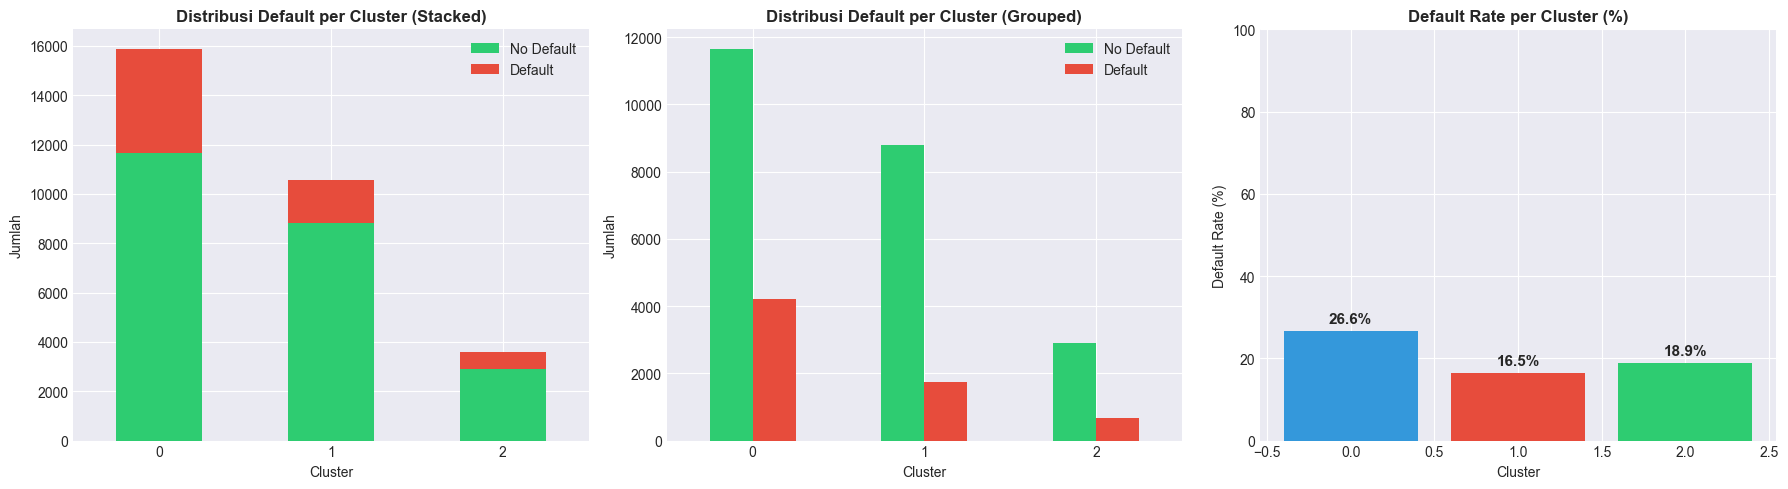


📊 CHI-SQUARE TEST (Independensi Cluster vs Default)
Chi-Square Statistic: 403.7996
P-value: 0.000000
Degrees of Freedom: 2

✅ Kesimpulan: Ada hubungan SIGNIFIKAN antara Cluster dan Default Status
   (p-value < 0.05, menolak H0)

💡 INTERPRETASI CLUSTER

🔹 Cluster 0:
   • Total nasabah: 15872
   • Default rate: 26.61%
   • Tingkat risiko: SEDANG 🔸

🔹 Cluster 1:
   • Total nasabah: 10543
   • Default rate: 16.47%
   • Tingkat risiko: RENDAH ✅

🔹 Cluster 2:
   • Total nasabah: 3585
   • Default rate: 18.86%
   • Tingkat risiko: RENDAH ✅


In [17]:
# ========================================
# ANALISIS HUBUNGAN CLUSTER DAN DEFAULT
# ========================================

print("🔗 ANALISIS HUBUNGAN CLUSTER DENGAN STATUS DEFAULT")
print("="*60)

# Crosstab antara Cluster dan TARGET
cluster_target_crosstab = pd.crosstab(df_clustered['Cluster'], 
                                      df_clustered['TARGET'], 
                                      margins=True)

print("\n📊 Crosstab: Cluster vs Default Status")
print(cluster_target_crosstab)

# Persentase default per cluster
cluster_target_pct = pd.crosstab(df_clustered['Cluster'], 
                                 df_clustered['TARGET'], 
                                 normalize='index') * 100

print("\n📈 Persentase Default per Cluster:")
print(cluster_target_pct)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Stacked Bar Chart
cluster_target_crosstab_no_margin = pd.crosstab(df_clustered['Cluster'], 
                                                 df_clustered['TARGET'])
cluster_target_crosstab_no_margin.plot(kind='bar', stacked=True, ax=axes[0],
                                      color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribusi Default per Cluster (Stacked)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Jumlah')
axes[0].legend(['No Default', 'Default'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2. Grouped Bar Chart
cluster_target_crosstab_no_margin.plot(kind='bar', ax=axes[1],
                                      color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Distribusi Default per Cluster (Grouped)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Jumlah')
axes[1].legend(['No Default', 'Default'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# 3. Default Rate (%)
default_rate_per_cluster = cluster_target_pct[1]  # Kolom 1 = Default
axes[2].bar(default_rate_per_cluster.index, default_rate_per_cluster.values,
           color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('Default Rate per Cluster (%)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_ylim([0, 100])

for i, v in enumerate(default_rate_per_cluster.values):
    axes[2].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Analisis Chi-Square Test
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(cluster_target_crosstab_no_margin)

print("\n" + "="*60)
print("📊 CHI-SQUARE TEST (Independensi Cluster vs Default)")
print("="*60)
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("\n✅ Kesimpulan: Ada hubungan SIGNIFIKAN antara Cluster dan Default Status")
    print("   (p-value < 0.05, menolak H0)")
else:
    print("\n⚠️  Kesimpulan: TIDAK ada hubungan signifikan antara Cluster dan Default Status")
    print("   (p-value >= 0.05, gagal menolak H0)")

# Interpretasi per cluster
print("\n" + "="*60)
print("💡 INTERPRETASI CLUSTER")
print("="*60)

for cluster_id in range(k_optimal):
    default_rate = cluster_target_pct.loc[cluster_id, 1]
    cluster_size = cluster_target_crosstab.loc[cluster_id, 'All']
    
    print(f"\n🔹 Cluster {cluster_id}:")
    print(f"   • Total nasabah: {cluster_size}")
    print(f"   • Default rate: {default_rate:.2f}%")
    
    if default_rate > 30:
        risk_level = "TINGGI ⚠️"
    elif default_rate > 20:
        risk_level = "SEDANG 🔸"
    else:
        risk_level = "RENDAH ✅"
    
    print(f"   • Tingkat risiko: {risk_level}")

## 5.2 Ringkasan & Kesimpulan Akhir

In [18]:
# ========================================
# RINGKASAN & KESIMPULAN AKHIR
# ========================================

print("="*70)
print(" "*15 + "📊 RINGKASAN HASIL ANALISIS 📊")
print("="*70)

print("\n" + "🗂️  INFORMASI DATASET".center(70, "="))
print(f"""
Dataset: Default of Credit Card Clients
Sumber: UCI Machine Learning Repository
Jumlah Data: {df.shape[0]:,} records
Jumlah Fitur: {df.shape[1]} (23 fitur + 1 target)
Target Variable: Default Payment Next Month (0=No Default, 1=Default)
Class Distribution: 
  - No Default: {(df['TARGET']==0).sum():,} ({(df['TARGET']==0).sum()/len(df)*100:.1f}%)
  - Default: {(df['TARGET']==1).sum():,} ({(df['TARGET']==1).sum()/len(df)*100:.1f}%)
""")

print("\n" + "🤖 HASIL KLASIFIKASI (SVM)".center(70, "="))
print(f"""
Model Terbaik: SVM dengan kernel {best_kernel.upper()}
Data Split: 80% Training ({len(y_train):,} samples), 20% Testing ({len(y_test):,} samples)

Performa Model:
┌─────────────────────────────────────────────────────────────┐
│  Accuracy:   {svm_results[best_kernel]['accuracy']:.4f} ({svm_results[best_kernel]['accuracy']*100:.2f}%)                                     │
│  Precision:  {svm_results[best_kernel]['precision']:.4f} ({svm_results[best_kernel]['precision']*100:.2f}%)                                     │
│  Recall:     {svm_results[best_kernel]['recall']:.4f} ({svm_results[best_kernel]['recall']*100:.2f}%)                                     │
│  F1-Score:   {svm_results[best_kernel]['f1_score']:.4f} ({svm_results[best_kernel]['f1_score']*100:.2f}%)                                     │
│  ROC-AUC:    {svm_results[best_kernel]['roc_auc']:.4f} ({svm_results[best_kernel]['roc_auc']*100:.2f}%)                                     │
└─────────────────────────────────────────────────────────────┘

Perbandingan Kernel:
""")
display(comparison_df)

print("\n" + "🎯 HASIL CLUSTERING (K-MEANS)".center(70, "="))
print(f"""
Jumlah Cluster Optimal: {k_optimal} cluster
Metode Penentuan: Elbow Method + Silhouette Score

Evaluasi Clustering:
┌─────────────────────────────────────────────────────────────┐
│  Silhouette Score:        {sil_score:.4f}                              │
│  Davies-Bouldin Score:    {db_score:.4f}                              │
│  Calinski-Harabasz Score: {ch_score:.2f}                           │
└─────────────────────────────────────────────────────────────┘

Distribusi Data per Cluster:
""")
for i in range(k_optimal):
    count = (df_clustered['Cluster'] == i).sum()
    pct = count / len(df_clustered) * 100
    default_rate = df_clustered[df_clustered['Cluster']==i]['TARGET'].mean() * 100
    print(f"  Cluster {i}: {count:,} nasabah ({pct:.1f}%) - Default Rate: {default_rate:.1f}%")

print("\n" + "💡 KESIMPULAN & REKOMENDASI".center(70, "="))
print(f"""
1. KLASIFIKASI (SVM):
   ✅ Model SVM dengan kernel {best_kernel.upper()} mampu memprediksi default dengan 
      akurasi {svm_results[best_kernel]['accuracy']*100:.1f}%.
   {'✅' if svm_results[best_kernel]['recall'] > 0.5 else '⚠️'} Model dapat mendeteksi {svm_results[best_kernel]['recall']*100:.1f}% dari kasus default yang sebenarnya.
   {'✅' if svm_results[best_kernel]['precision'] > 0.7 else '⚠️'} Precision {svm_results[best_kernel]['precision']*100:.1f}% menunjukkan akurasi prediksi positif.
   
   📌 Rekomendasi: Model ini dapat digunakan sebagai early warning system
      untuk mengidentifikasi nasabah berisiko tinggi.

2. CLUSTERING (K-MEANS):
   ✅ Nasabah berhasil dikelompokkan ke dalam {k_optimal} cluster dengan karakteristik
      yang berbeda.
   {'✅' if sil_score > 0.3 else '⚠️'} Silhouette Score {sil_score:.3f} menunjukkan kualitas clustering yang 
      {'baik' if sil_score > 0.5 else 'cukup' if sil_score > 0.3 else 'perlu ditingkatkan'}.
   ✅ Setiap cluster memiliki pola perilaku kredit yang khas.
   
   📌 Rekomendasi: Hasil clustering dapat digunakan untuk:
      - Segmentasi nasabah untuk strategi marketing
      - Personalisasi limit kredit per segmen
      - Identifikasi cluster berisiko tinggi

3. INTEGRASI KEDUA METODE:
   ✅ Klasifikasi (Supervised) memberikan prediksi default yang spesifik
   ✅ Clustering (Unsupervised) memberikan insight tentang segmen nasabah
   📌 Kombinasi keduanya memberikan pemahaman komprehensif tentang
      risiko kredit dan karakteristik nasabah
""")

print("\n" + "🎓 PEMBELAJARAN & TANTANGAN".center(70, "="))
print("""
Pembelajaran:
• SVM efektif untuk klasifikasi binary dengan data berdimensi tinggi
• Scaling data sangat penting untuk performa SVM
• Elbow Method membantu menentukan jumlah cluster optimal
• Imbalanced data mempengaruhi performa model (78% vs 22%)

Tantangan:
• Dataset imbalanced memerlukan handling khusus
• Training SVM memakan waktu untuk dataset besar
• Interpretasi cluster dalam high-dimensional space sulit
• Trade-off antara Precision dan Recall

Pengembangan Lanjutan:
• Implementasi teknik handling imbalanced data (SMOTE, undersampling)
• Hyperparameter tuning dengan GridSearchCV
• Ensemble methods untuk meningkatkan performa
• Feature engineering untuk fitur yang lebih informatif
""")

print("\n" + "="*70)
print(" "*20 + "✅ ANALISIS SELESAI ✅")
print("="*70)

# Simpan hasil ke file CSV
print("\n💾 Menyimpan hasil ke file...")
df_clustered.to_csv('datasets/credit_card_with_clusters.csv', index=False)
print("✅ Hasil clustering disimpan ke: datasets/credit_card_with_clusters.csv")

# Simpan summary metrics
summary = {
    'SVM_Best_Kernel': best_kernel,
    'SVM_Accuracy': svm_results[best_kernel]['accuracy'],
    'SVM_Precision': svm_results[best_kernel]['precision'],
    'SVM_Recall': svm_results[best_kernel]['recall'],
    'SVM_F1_Score': svm_results[best_kernel]['f1_score'],
    'SVM_ROC_AUC': svm_results[best_kernel]['roc_auc'],
    'KMeans_Optimal_K': k_optimal,
    'KMeans_Silhouette': sil_score,
    'KMeans_Davies_Bouldin': db_score,
    'KMeans_Calinski_Harabasz': ch_score
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('datasets/model_summary.csv', index=False)
print("✅ Summary metrics disimpan ke: datasets/model_summary.csv")

print("\n🎉 Semua proses selesai! Notebook siap untuk dipresentasikan.")

               📊 RINGKASAN HASIL ANALISIS 📊

========================🗂️  INFORMASI DATASET=========================

Dataset: Default of Credit Card Clients
Sumber: UCI Machine Learning Repository
Jumlah Data: 30,000 records
Jumlah Fitur: 25 (23 fitur + 1 target)
Target Variable: Default Payment Next Month (0=No Default, 1=Default)
Class Distribution: 
  - No Default: 23,364 (77.9%)
  - Default: 6,636 (22.1%)


======================🤖 HASIL KLASIFIKASI (SVM)=======================

Model Terbaik: SVM dengan kernel RBF
Data Split: 80% Training (24,000 samples), 20% Testing (6,000 samples)

Performa Model:
┌─────────────────────────────────────────────────────────────┐
│  Accuracy:   0.8160 (81.60%)                                     │
│  Precision:  0.6652 (66.52%)                                     │
│  Recall:     0.3384 (33.84%)                                     │
│  F1-Score:   0.4486 (44.86%)                                     │
│  ROC-AUC:    0.7210 (72.10%)                  

,Kernel,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,linear,0.808000,0.683438,0.245667,0.361419,0.689807
1,rbf,0.816000,0.665185,0.338357,0.448551,0.721000
2,poly,0.807333,0.682303,0.241145,0.356347,0.700143



=====================🎯 HASIL CLUSTERING (K-MEANS)=====================

Jumlah Cluster Optimal: 3 cluster
Metode Penentuan: Elbow Method + Silhouette Score

Evaluasi Clustering:
┌─────────────────────────────────────────────────────────────┐
│  Silhouette Score:        0.1847                              │
│  Davies-Bouldin Score:    1.6673                              │
│  Calinski-Harabasz Score: 6197.51                           │
└─────────────────────────────────────────────────────────────┘

Distribusi Data per Cluster:

  Cluster 0: 15,872 nasabah (52.9%) - Default Rate: 26.6%
  Cluster 1: 10,543 nasabah (35.1%) - Default Rate: 16.5%
  Cluster 2: 3,585 nasabah (11.9%) - Default Rate: 18.9%

======================💡 KESIMPULAN & REKOMENDASI======================

1. KLASIFIKASI (SVM):
   ✅ Model SVM dengan kernel RBF mampu memprediksi default dengan 
      akurasi 81.6%.
   ⚠️ Model dapat mendeteksi 33.8% dari kasus default yang sebenarnya.
   ⚠️ Precision 66.5% menunjukkan akura